# Naturalness Scores for double mutants

**Goal:** Evaluate different "double mutant naturalness" strategies.

**Background:** Many strategies exist in literature. (TODO: list some prior results). I want to try a few using ESMC-600M, and see how they work for myself.

**Approach:** For each single mutant of [SPG1](https://foldy.lbl.gov/fold/7617), I did a forward run through ESMC-600M. I'll first see how different strategies are correlated to activity with Spearman rho.

In [17]:
import pandas as pd
import dask.dataframe as dd


In [18]:
pg_df = pd.read_csv('notebooks/jacob/data/DMS_substitutions.csv')

In [19]:
spg_metadata = pg_df[pg_df['DMS_id'] == 'SPG1_STRSG_Olson_2014'].iloc[0]
spg_wt_seq = spg_metadata['target_seq']
spg_filepath = spg_metadata['DMS_filename']

spg_df = pd.read_csv(f'notebooks/jacob/data/DMS_ProteinGym_substitutions/{spg_filepath}')
spg_df['seq_id'] = spg_df.mutant.apply(lambda x: x.replace(':', '_'))
spg_df['first_mut'] = spg_df.seq_id.apply(lambda x: x.split('_')[0] if x.count('_') == 1 else pd.NA)
spg_df['second_mut'] = spg_df.seq_id.apply(lambda x: x.split('_')[1] if x.count('_') == 1 else pd.NA)
spg_df['first_mut_locus'] = spg_df.first_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA)
spg_df['second_mut_locus'] = spg_df.second_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA)
spg_df.drop(columns=['mutated_sequence'], inplace=True)
spg_df

,mutant,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus
0,Q228R:T279L,0.328504,1,Q228R_T279L,Q228R,T279L,228,279
1,Q228K:T279A,0.702656,1,Q228K_T279A,Q228K,T279A,228,279
2,Q228K:T279C,0.422857,1,Q228K_T279C,Q228K,T279C,228,279
3,Q228K:T279D,0.263417,1,Q228K_T279D,Q228K,T279D,228,279
4,Q228K:T279E,0.734820,1,Q228K_T279E,Q228K,T279E,228,279
...,...,...,...,...,...,...,...,...
536957,E282Q:T251Q,0.202574,1,E282Q_T251Q,E282Q,T251Q,282,251
536958,E282Q:T251P,-0.289294,1,E282Q_T251P,E282Q,T251P,282,251
536959,E282Q:T251N,-0.688549,1,E282Q_T251N,E282Q,T251N,282,251
536960,E282Q:T270E,-0.916291,1,E282Q_T270E,E282Q,T270E,282,270


<Axes: xlabel='None'>

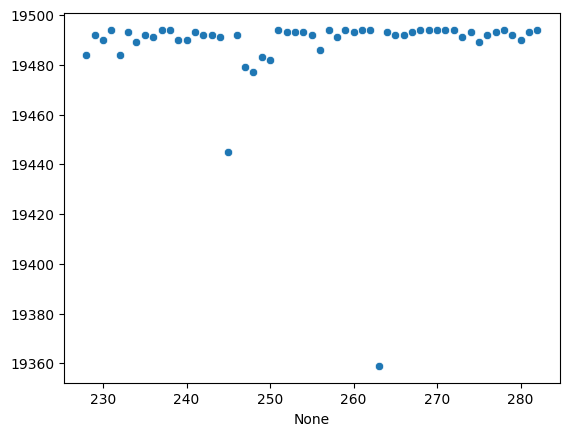

In [20]:
import seaborn as sns
spg_counts = pd.concat([
  spg_df.first_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA),
  spg_df.second_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA)
], ignore_index=True).value_counts()
sns.scatterplot(x=spg_counts.index, y=spg_counts.values)

In [21]:
raw_naturalness_dd = dd.read_parquet("notebooks/jacob/data/spg1_logits_600m_doubles_melted.parquet")
raw_naturalness_dd['base_id_subseq_id'] = raw_naturalness_dd['base_seq_id'] + '_' + raw_naturalness_dd['seq_id']
raw_naturalness_dd = raw_naturalness_dd.set_index('base_id_subseq_id')  # Dask doesn't support inplace
raw_naturalness_dd = raw_naturalness_dd.drop(columns=['base_seq_id', 'seq_id'])
raw_naturalness_dd = raw_naturalness_dd.repartition(npartitions=20)
raw_naturalness_dd = raw_naturalness_dd.persist()

# raw_naturalness = pd.read_parquet("notebooks/jacob/data/spg1_logits_600m_doubles_melted.parquet")


# from tqdm import tqdm

# raw_naturalness = pd.read_csv('notebooks/jacob/data/spg1_logits_600m_doubles_melted.csv')
# # Initialize an empty list to store the chunked dataframes
# dfs = []

# # Read the CSV file in chunks
# reader = pd.read_csv('notebooks/jacob/data/spg1_logits_600m_doubles_melted.csv', chunksize=10000)  # Adjust the chunksize as per your memory capacity

# # Iterate through each chunk and append it to the list
# for chunk in tqdm(reader):
#     dfs.append(chunk)

# # Concatenate all the chunks into a single dataframe
# raw_naturalness = pd.concat(dfs, ignore_index=True)

# raw_naturalness.to_parquet("notebooks/jacob/data/spg1_logits_600m_doubles_melted.parquet", engine="pyarrow")  # Fast, compressed storage

In [22]:
base_naturalness_df = raw_naturalness_dd[raw_naturalness_dd['base_id_subseq_id'].str.startswith('WT')].compute()
base_naturalness_df['seq_id'] = base_naturalness_df['base_id_subseq_id'].apply(lambda x: x.split('_')[1])


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_59901/3693874065.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_naturalness_df['seq_id'] = base_naturalness_df['base_id_subseq_id'].apply(lambda x: x.split('_')[1])


In [23]:
wt_scores = base_naturalness_df[base_naturalness_df.seq_id.apply(lambda x: x[0] == x[-1])].copy()
wt_scores['locus'] = wt_scores.seq_id.apply(lambda x: int(x[1:-1]))
wt_scores.set_index('locus', inplace=True)
wt_scores = wt_scores[['probability']]
wt_scores.head()


,probability
locus,
1,1.000000
2,0.062256
3,0.302734
4,0.416016
5,0.449219


## First compute the linear model of naturalness.

In [24]:
import numpy as np
spg_df_plus = spg_df.copy()
spg_df_plus = pd.merge(
  spg_df_plus,
  base_naturalness_df.set_index('seq_id')[['probability']].rename(columns={'probability': 'second_mut_prob'}),
  left_on='second_mut',
  right_on='seq_id',
  how='left',
)
spg_df_plus = pd.merge(
  spg_df_plus,
  base_naturalness_df.set_index('seq_id')[['probability']].rename(columns={'probability': 'first_mut_prob'}),
  left_on='first_mut',
  right_on='seq_id',
  how='left',
)
spg_df_plus = pd.merge(
  spg_df_plus,
  wt_scores.rename(columns={'probability': 'first_mut_wt_prob'}),
  left_on='first_mut_locus',
  right_on='locus',
  how='left',
)
spg_df_plus = pd.merge(
  spg_df_plus,
  wt_scores.rename(columns={'probability': 'second_mut_wt_prob'}),
  left_on='second_mut_locus',
  right_on='locus',
  how='left',
)



In [25]:
import numpy as np

def compute_double_mutant_naturalness(row):
  if (row['first_mut_wt_prob'] is pd.NA or
      row['second_mut_wt_prob'] is pd.NA or
      row['first_mut_prob'] is pd.NA or
      row['second_mut_prob'] is pd.NA):
    return pd.NA
  score1 = row['first_mut_prob'] / row['first_mut_wt_prob']
  score2 = row['second_mut_prob'] / row['second_mut_wt_prob']
  return score1 * score2

spg_df_plus['double_mutant_naturalness'] = spg_df_plus.apply(compute_double_mutant_naturalness, axis=1)
spg_df_plus['log_double_mutant_naturalness'] = np.log(spg_df_plus['double_mutant_naturalness'])
spg_df_plus.head()


,mutant,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus,second_mut_prob,first_mut_prob,first_mut_wt_prob,second_mut_wt_prob,double_mutant_naturalness,log_double_mutant_naturalness
0,Q228R:T279L,0.328504,1,Q228R_T279L,Q228R,T279L,228,279,0.000324,0.003235,0.00824,0.964844,0.000132,-8.933192
1,Q228K:T279A,0.702656,1,Q228K_T279A,Q228K,T279A,228,279,0.002121,0.069336,0.00824,0.964844,0.018498,-3.990098
2,Q228K:T279C,0.422857,1,Q228K_T279C,Q228K,T279C,228,279,0.000006,0.069336,0.00824,0.964844,0.000049,-9.931788
3,Q228K:T279D,0.263417,1,Q228K_T279D,Q228K,T279D,228,279,0.000324,0.069336,0.00824,0.964844,0.002828,-5.868215
4,Q228K:T279E,0.734820,1,Q228K_T279E,Q228K,T279E,228,279,0.001129,0.069336,0.00824,0.964844,0.009848,-4.620507


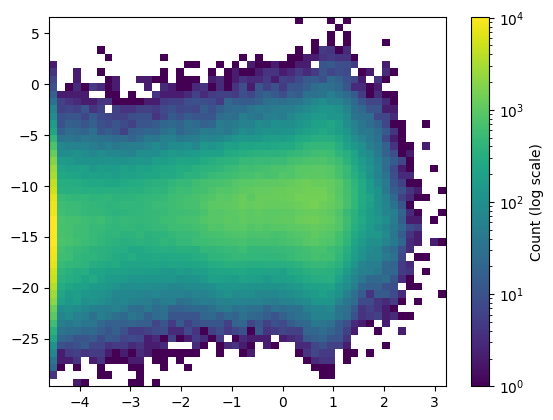

In [26]:
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

# hist = plt.hexbin(spg_df['DMS_score'], spg_df['log_double_mutant_naturalness'], gridsize=50, cmap='viridis', mincnt=1, norm=LogNorm())
hist = plt.hist2d(spg_df_plus.dropna()['DMS_score'], spg_df_plus.dropna()['log_double_mutant_naturalness'], bins=50, cmap='viridis', norm=LogNorm())

plt.colorbar(hist[3], label='Count (log scale)')
# sns.scatterplot(x='DMS_score', y='double_mutant_naturalness', data=spg_df)
# plt.yscale('log')

In [27]:
# Compute the correlation between DMS_score and log_double_mutant_naturalness
corr = spg_df_plus.dropna()[['DMS_score', 'log_double_mutant_naturalness']].corr(method='spearman')
print(f"Correlation: {corr.iloc[0, 1]:.2f}")


Correlation: 0.27


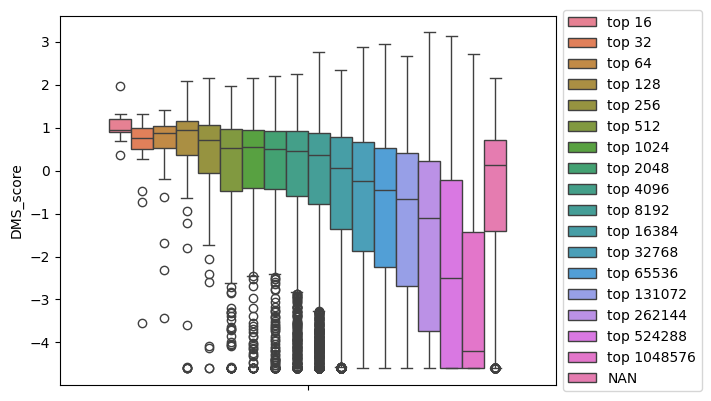

In [28]:
# Show the boxplot of DMS scores for the top 16, 32, 64, 128 mutants
def rank_to_category(rank):
  if pd.isna(rank):
    return 'NAN'
  cutoff = 16
  while rank > cutoff:
    cutoff *= 2
  return f'top {cutoff}'
spg_df_plus.sort_values(by='double_mutant_naturalness', ascending=False, inplace=True)
spg_df_plus['naturalness_category'] = spg_df_plus['double_mutant_naturalness'].rank(ascending=False).apply(rank_to_category)
sns.boxplot(hue='naturalness_category', y='DMS_score', data=spg_df_plus)
# Put legend on right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


In [29]:
spg_df_plus[spg_df_plus.DMS_score > 2.5]

,mutant,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus,second_mut_prob,first_mut_prob,first_mut_wt_prob,second_mut_wt_prob,double_mutant_naturalness,log_double_mutant_naturalness,naturalness_category
456838,D273Y:I232V,2.772589,1,D273Y_I232V,D273Y,I232V,273,232,0.828125,2.212524e-03,0.738281,0.099121,2.503779e-02,-3.687369,top 8192
229848,A250H:I232V,2.871680,1,A250H_I232V,A250H,I232V,250,232,0.828125,1.230240e-04,0.531250,0.099121,1.934731e-03,-6.247787,top 32768
234571,A250Y:I232V,2.803360,1,A250Y_I232V,A250Y,I232V,250,232,0.828125,1.230240e-04,0.531250,0.099121,1.934731e-03,-6.247787,top 32768
1573,Q228F:T277I,2.525729,1,Q228F_T277I,Q228F,T277I,228,277,0.008301,1.846313e-03,0.008240,0.964844,1.927763e-03,-6.251395,top 32768
397197,D266H:E245V,2.564949,1,D266H_E245V,D266H,E245V,266,245,0.012329,1.147461e-02,0.550781,0.193359,1.328388e-03,-6.623789,top 32768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229395,A250H:T275Q,2.505526,1,A250H_T275Q,A250H,T275Q,250,275,0.000022,1.230240e-04,0.531250,0.964844,5.293168e-09,-19.056849,top 524288
187783,D248W:K276T,2.564949,1,D248W_K276T,D248W,K276T,248,276,0.001259,2.205372e-06,0.976562,0.949219,2.994949e-09,-19.626338,top 524288
234970,A250W:T277F,2.708050,1,A250W_T277F,A250W,T277F,250,277,0.000050,2.741814e-05,0.531250,0.964844,2.652683e-09,-19.747694,top 524288
231796,A250F:T275H,3.113515,1,A250F_T275H,A250F,T275H,250,275,0.000005,9.584427e-05,0.531250,0.964844,9.194842e-10,-20.807208,top 524288


> Ok that went surprisingly well. But note that the top ranked performers all have poor naturalness scores.

# Partial Likelihood Naturalness (a more advanced score)

We want to calculate the naturalness for a double mutant in a more interesting way.

$$
N(s_{i,a},s_{j,b}) = \text{Naturalness of sequence with residue i mutated to a and j mutated to b} \\
$$

### Full model:
Difficult to compute, but it's what we're approximating
$$
N_{full}(s_{i,a},s_{j,b}) = \frac{P(s_{i,a},s_{j,b}|s_{i,a}{s_j,b})}{P(s_{i,wt},s_{j,wt}|s_{i,wt}{s_j,wt})}
$$

### Linear model:
$$
N_{linear}(s_{i,a},s_{j,b}) = \frac{P(s_{i,a}|s_{wt})}{P(s_{i,wt}|s_{wt})}\frac{P(s_{j,b}|s_{wt})}{P(s_{j,wt}|s_{wt})}
$$

### Partial model:

$$
N_{partial}(s_{i,a},s_{j,b}) = \frac{P(s_{i,a}|s_{i,wt}s_{j,b})}{P(s_{i,wt}|s_{i,wt}s_{j,b})}\frac{P(s_{j,b}|s_{i,a}s_{j,wt})}{P(s_{j,wt}|s_{i,a}s_{j,wt})}
$$

### BAD partial model...
This is what I implemented before, but I don't think it makes sense
$$
N_{partial}(s_{i,a},s_{j,b}) = \frac{P(s_{i,a}|s_{i,wt}s_{j,b})}{P(s_{i,wt}|s_{i,wt}s_{j,\mathbf{wt}})}\frac{P(s_{j,b}|s_{i,a}s_{j,wt})}{P(s_{j,wt}|s_{i,\mathbf{wt}}s_{j,wt})}
$$


In [60]:
spg_df_with_pairs = spg_df.copy()
spg_df_with_pairs = spg_df_with_pairs.dropna()

In [ ]:
spg_df_with_pairs['first_then_second'] = spg_df_with_pairs.apply(lambda row: row['first_mut'] + '_' + row['second_mut'], axis=1)
spg_df_with_pairs['second_then_first'] = spg_df_with_pairs.apply(lambda row: row['second_mut'] + '_' + row['first_mut'], axis=1)
spg_df_with_pairs['first_then_wt'] = spg_df_with_pairs.apply(lambda row: row['first_mut'] + '_' + row['second_mut'][:-1] + row['second_mut'][0], axis=1)
spg_df_with_pairs['second_then_wt'] = spg_df_with_pairs.apply(lambda row: row['second_mut'] + '_' + row['first_mut'][:-1] + row['first_mut'][0], axis=1)
spg_df_with_pairs.head()

,mutant,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus,first_then_second,second_then_first,first_then_wt,second_then_wt
0,Q228R:T279L,0.328504,1,Q228R_T279L,Q228R,T279L,228,279,Q228R_T279L,T279L_Q228R,Q228R_T279T,T279L_Q228Q
1,Q228K:T279A,0.702656,1,Q228K_T279A,Q228K,T279A,228,279,Q228K_T279A,T279A_Q228K,Q228K_T279T,T279A_Q228Q
2,Q228K:T279C,0.422857,1,Q228K_T279C,Q228K,T279C,228,279,Q228K_T279C,T279C_Q228K,Q228K_T279T,T279C_Q228Q
3,Q228K:T279D,0.263417,1,Q228K_T279D,Q228K,T279D,228,279,Q228K_T279D,T279D_Q228K,Q228K_T279T,T279D_Q228Q
4,Q228K:T279E,0.734820,1,Q228K_T279E,Q228K,T279E,228,279,Q228K_T279E,T279E_Q228K,Q228K_T279T,T279E_Q228Q


In [62]:
spg_df_with_pairs = raw_naturalness_dd.rename(columns={'probability': 'probability_first_then_second'}).merge(
  spg_df_with_pairs.set_index('first_then_second'),
  left_index=True,
  right_index=True,
  how='right',
).compute()
spg_df_with_pairs.reset_index(inplace=True, drop=False)

In [64]:
spg_df_with_pairs = raw_naturalness_dd.rename(columns={'probability': 'probability_second_then_first'}).merge(
  spg_df_with_pairs.set_index('second_then_first'),
  left_index=True,
  right_index=True,
  how='right',
).compute()
spg_df_with_pairs.reset_index(inplace=True, drop=False)

In [65]:
spg_df_with_pairs = raw_naturalness_dd.rename(columns={'probability': 'probability_first_then_wt'}).merge(
  spg_df_with_pairs.set_index('first_then_wt'),
  left_index=True,
  right_index=True,
  how='right',
).compute()
spg_df_with_pairs.reset_index(inplace=True, drop=False)

In [66]:
spg_df_with_pairs = raw_naturalness_dd.rename(columns={'probability': 'probability_second_then_wt'}).merge(
  spg_df_with_pairs.set_index('second_then_wt'),
  left_index=True,
  right_index=True,
  how='right',
).compute()
spg_df_with_pairs.reset_index(inplace=True, drop=False)

In [67]:
spg_df_with_pairs.head()

,second_then_wt,probability_second_then_wt,first_then_wt,probability_first_then_wt,second_then_first,probability_second_then_first,first_then_second,probability_first_then_second,mutant,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus
0,A249C_A246A,0.628906,A246C_A249A,0.871094,A249C_A246C,0.000224,A246C_A249C,0.000227,A246C:A249C,-1.041454,1,A246C_A249C,A246C,A249C,246,249
1,A249C_A246A,0.628906,A246D_A249A,0.886719,A249C_A246D,0.007874,A246D_A249C,0.000026,A246D:A249C,-1.791759,1,A246D_A249C,A246D,A249C,246,249
2,A249C_A246A,0.628906,A246E_A249A,0.875000,A249C_A246E,0.027588,A246E_A249C,0.000024,A246E:A249C,-1.545196,1,A246E_A249C,A246E,A249C,246,249
3,A249C_A246A,0.628906,A246F_A249A,0.843750,A249C_A246F,0.005432,A246F_A249C,0.000023,A246F:A249C,-2.189790,1,A246F_A249C,A246F,A249C,246,249
4,A249C_A246A,0.628906,A246G_A249A,0.886719,A249C_A246G,0.011475,A246G_A249C,0.000019,A246G:A249C,-0.826679,1,A246G_A249C,A246G,A249C,246,249


In [77]:
spg_df_with_pairs['double_mutant_naturalness'] = spg_df_with_pairs.apply(lambda row: (
  row['probability_first_then_second'] * row['probability_second_then_first'] / (row['probability_first_then_wt'] * row['probability_second_then_wt'])
), axis=1)

In [121]:
merged = pd.merge(
    spg_df_plus,
    spg_df_with_pairs,
    on='mutant',
    how='left',
    suffixes=('_linear', '_partial')
)
merged['is_really_good'] = merged.DMS_score_partial > 2.0
merged.head()

,mutant,DMS_score_linear,DMS_score_bin_linear,seq_id_linear,first_mut_linear,second_mut_linear,first_mut_locus_linear,second_mut_locus_linear,second_mut_prob,first_mut_prob,...,DMS_score_partial,DMS_score_bin_partial,seq_id_partial,first_mut_partial,second_mut_partial,first_mut_locus_partial,second_mut_locus_partial,double_mutant_naturalness_partial,naturalness_category_partial,is_really_good
0,I232V:Q228T,0.367725,1,I232V_Q228T,I232V,Q228T,232,228,0.742188,0.828125,...,0.367725,1.0,I232V_Q228T,I232V,Q228T,232,228,664.305470,top 16,False
1,L233I:Q228T,1.298696,1,L233I_Q228T,L233I,Q228T,233,228,0.742188,0.652344,...,1.298696,1.0,L233I_Q228T,L233I,Q228T,233,228,454.397105,top 16,False
2,Q228T:V255A,0.963544,1,Q228T_V255A,Q228T,V255A,228,255,0.753906,0.742188,...,0.963544,1.0,Q228T_V255A,Q228T,V255A,228,255,457.074490,top 16,False
3,E245K:Q228T,1.146960,1,E245K_Q228T,E245K,Q228T,245,228,0.742188,0.671875,...,1.146960,1.0,E245K_Q228T,E245K,Q228T,245,228,245.180882,top 16,False
4,E268V:Q228T,1.321427,1,E268V_Q228T,E268V,Q228T,268,228,0.742188,0.554688,...,1.321427,1.0,E268V_Q228T,E268V,Q228T,268,228,190.753361,top 16,False


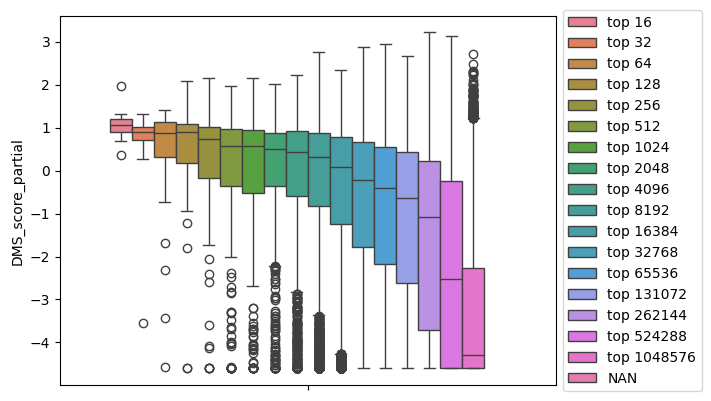

In [123]:
from matplotlib import pyplot as plt
# Show the boxplot of DMS scores for the top 16, 32, 64, 128 mutants
def rank_to_category(rank):
  if pd.isna(rank):
    return 'NAN'
  cutoff = 16
  while rank > cutoff:
    cutoff *= 2
  return f'top {cutoff}'
merged.sort_values(by='double_mutant_naturalness_partial', ascending=False, inplace=True)
merged['partial_naturalness_category'] = merged['double_mutant_naturalness_partial'].rank(ascending=False).apply(rank_to_category)
sns.boxplot(hue='partial_naturalness_category', y='DMS_score_partial', data=merged)
# Put legend on right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


## Compare the two

Text(0, 0.5, 'Pairwise model for epistasis (expensive to compute)')

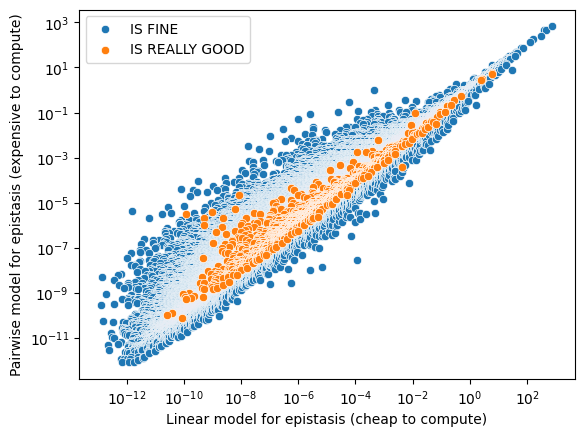

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(
    data=merged[~merged.is_really_good],
    x='double_mutant_naturalness_linear',
    y='double_mutant_naturalness_partial',
    label='IS FINE'
)
sns.scatterplot(
    data=merged[merged.is_really_good],
    x='double_mutant_naturalness_linear',
    y='double_mutant_naturalness_partial',
    label='IS REALLY GOOD'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Linear model for epistasis (cheap to compute)')
plt.ylabel('Pairwise model for epistasis (expensive to compute)')


/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


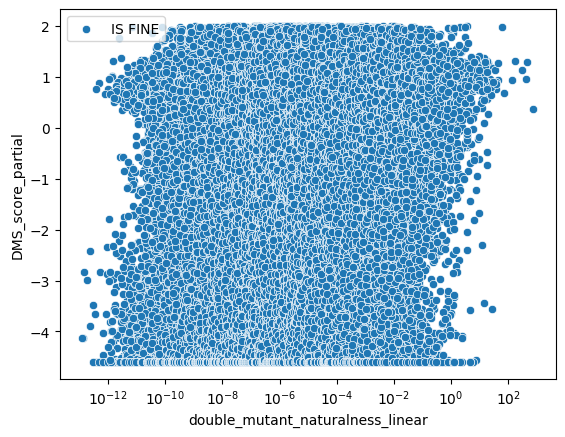

In [165]:

sns.scatterplot(
    data=merged[~merged.is_really_good],
    x='double_mutant_naturalness_linear',
    y='DMS_score_partial',
    label='IS FINE'
)
plt.xscale('log')

In [117]:
spg_df_plus[spg_df_plus.mutant.isin(['A250F', 'D266N'])]

,mutant,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus,second_mut_prob,first_mut_prob,first_mut_wt_prob,second_mut_wt_prob,double_mutant_naturalness,log_double_mutant_naturalness,naturalness_category
227301,A250F,1.842672,1,A250F,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NAN
399190,D266N,0.989488,1,D266N,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NAN


In [118]:
wt_scores

,probability
locus,
1,1.000000
2,0.062256
3,0.302734
4,0.416016
5,0.449219
...,...
444,0.281250
445,0.976562
446,0.968750


In [114]:
merged[merged.is_really_good].iloc[10]

mutant                               A250F:D266N
DMS_score_linear                        2.545531
DMS_score_bin_linear                           1
seq_id_linear                        A250F_D266N
first_mut_linear                           A250F
second_mut_linear                          D266N
first_mut_locus_linear                       250
second_mut_locus_linear                      266
second_mut_prob                         0.108887
first_mut_prob                          0.000096
first_mut_wt_prob                        0.53125
second_mut_wt_prob                      0.550781
double_mutant_naturalness_linear        0.000036
log_double_mutant_naturalness         -10.241293
naturalness_category_linear           top 131072
second_then_wt                       D266N_A250A
probability_second_then_wt              0.582031
first_then_wt                        A250F_D266D
probability_first_then_wt               0.511719
second_then_first                    D266N_A250F
probability_second_t

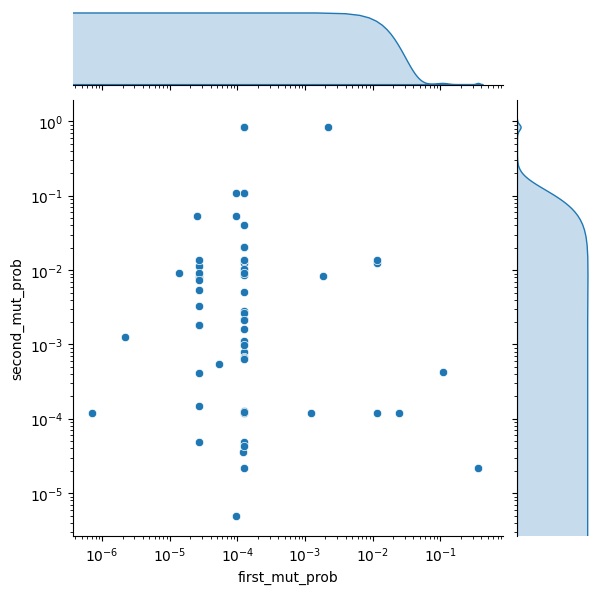

In [111]:
import seaborn as sns

g = sns.JointGrid(
    data=merged[merged.is_really_good],
    x='first_mut_prob',
    y='second_mut_prob'
)

# Add the scatter plot to the main area
g.plot_joint(sns.scatterplot)

# Add KDE plots on the margins instead of histograms
g.plot_marginals(sns.kdeplot, fill=True)

# Set log scales for both axes
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')

# Set log scales for marginal plots
g.ax_marg_x.set_xscale('log')
g.ax_marg_y.set_yscale('log')


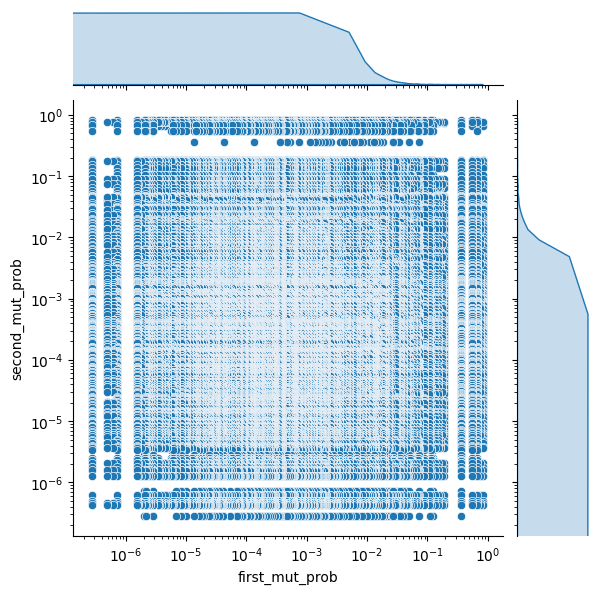

In [110]:
import seaborn as sns

g = sns.JointGrid(
    data=merged,
    x='first_mut_prob',
    y='second_mut_prob'
)

# Add the scatter plot to the main area
g.plot_joint(sns.scatterplot)

# Add KDE plots on the margins instead of histograms
g.plot_marginals(sns.kdeplot, fill=True)

# Set log scales for both axes
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')

# Set log scales for marginal plots
g.ax_marg_x.set_xscale('log')
g.ax_marg_y.set_yscale('log')


In [ ]:
import seaborn as sns

g = sns.JointGrid(
    data=merged[merged.is_really_good],
    x='first_mut_prob',
    y='second_mut_prob'
)

# Add the scatter plot to the main area
g.plot_joint(sns.scatterplot)

# Add KDE plots on the margins instead of histograms
g.plot_marginals(sns.kdeplot, fill=True)

# Set log scales for both axes
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')

# Set log scales for marginal plots
g.ax_marg_x.set_xscale('log')
g.ax_marg_y.set_yscale('log')


In [98]:
merged[merged.is_really_good].naturalness_category_partial.value_counts()

naturalness_category_partial
top 524288     34
top 262144     18
top 32768       4
top 131072      3
top 65536       2
top 8192        1
top 1048576     1
Name: count, dtype: int64

# Mutual Information

Can MI help us find those positive epistasis residue pairs?